# Verification — RQA parameter robustness

**Scope:** processed PPG, primary 60 s windows, and the existing `analysis_included=True`/processed-stationarity mask only. The analysis uses all 20 sessions. It does not refilter, relabel, resegment, run Raw PPG, or change the RQA core.

Frozen outside the sensitivity factor: `m=8`, `τ=0.16 s`, Euclidean distance, `l_min=v_min=2`, tie-safe fixed-RR thresholding, and the existing DET/LAM/TT definitions. Nominal parameters are not reselected from p-values.

Targeted experiments:

1. target recurrence rate: `0.01 / 0.02 / 0.03`;
2. Theiler corridor: `0.75× / 1.00× / 1.25×` the nominal `(m−1)×tau_samples` corridor.

In [1]:
# Setup, frozen protocol, cache identity, and CPU limits
import os
for variable in (
    "OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS",
):
    os.environ[variable] = "1"

import gc
import hashlib
import importlib
import json
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from joblib import Parallel, delayed, parallel_backend
from scipy.stats import rankdata, wilcoxon
from threadpoolctl import threadpool_limits


def find_project_root(start):
    for path in (start, *start.parents):
        if (path / "phase1" / "src").is_dir():
            return path
    raise FileNotFoundError("Cannot locate the project root.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / "phase1" / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from dataloader.loader import load_segmented_session
rqa_core = importlib.import_module("rqa.rqa")

REPRESENTATION = "Processed"
WINDOW_SIZE_S = 60
M = 8
TAU_S = 0.16
L_MIN = 2
V_MIN = 2
NOMINAL_RR = 0.02
RR_VALUES = (0.01, 0.02, 0.03)
THEILER_MULTIPLIERS = (0.75, 1.00, 1.25)
RR_TOLERANCE = 5e-5
METRICS = ("DET", "LAM", "TT")
N_BOOTSTRAP = 20_000
RANDOM_SEED = 20_260_914
N_WORKERS = max(1, (os.cpu_count() or 2) // 2)
STATE_NAMES = {0: "Awake", 1: "Drowsy"}

DATA_DIR = PROJECT_ROOT / "phase1" / "segmentated_data" / "dhdata"
NOMINAL_PATH = PROJECT_ROOT / "phase1" / "results" / "rqa" / "rqa_window_level.csv"
CACHE_DIR = PROJECT_ROOT / "phase1" / "results" / "rqa" / "verification"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

CORE_PATH = SRC_DIR / "rqa" / "rqa.py"
CONFIG = {
    "representation": REPRESENTATION,
    "window_size_s": WINDOW_SIZE_S,
    "m": M,
    "tau_s": TAU_S,
    "distance": "euclidean",
    "l_min": L_MIN,
    "v_min": V_MIN,
    "rr_values": RR_VALUES,
    "theiler_multipliers": THEILER_MULTIPLIERS,
    "rr_tolerance": RR_TOLERANCE,
    "core_sha256": hashlib.sha256(CORE_PATH.read_bytes()).hexdigest(),
}
CONFIG_HASH = hashlib.sha256(
    json.dumps(CONFIG, sort_keys=True).encode()
).hexdigest()
RR_CACHE = CACHE_DIR / f"rr_sensitivity_{CONFIG_HASH[:12]}.csv"
THEILER_CACHE = CACHE_DIR / f"theiler_sensitivity_{CONFIG_HASH[:12]}.csv"

display(pd.DataFrame([
    ["Primary data", "Processed PPG, 60 s, analysis_included=True"],
    ["Embedding", "m=8; τ=0.16 s"],
    ["Distance", "Euclidean"],
    ["Nominal RR", "0.02, tie-safe epsilon per window"],
    ["Nominal Theiler", "(m−1)×tau_samples"],
    ["Line thresholds", "l_min=v_min=2"],
    ["Headline / secondary", "DET / LAM, TT"],
    ["Workers", f"{N_WORKERS} of {os.cpu_count()} logical CPUs; 1 numerical thread/worker"],
], columns=["Item", "Frozen setting"]))

,Item,Frozen setting
0,Primary data,"Processed PPG, 60 s, analysis_included=True"
1,Embedding,m=8; τ=0.16 s
2,Distance,Euclidean
3,Nominal RR,"0.02, tie-safe epsilon per window"
4,Nominal Theiler,(m−1)×tau_samples
5,Line thresholds,l_min=v_min=2
6,Headline / secondary,"DET / LAM, TT"
7,Workers,8 of 16 logical CPUs; 1 numerical thread/worker


In [2]:
# Load the existing primary windows and align them to the nominal RQA cache
def session_number(path):
    return int(path.stem.rsplit("_", 1)[-1])


tasks = []
for path in sorted(DATA_DIR.glob("sample_*.npz"), key=session_number):
    batches, _ = load_segmented_session(
        path.stem,
        data_dir=DATA_DIR,
        window_sizes=WINDOW_SIZE_S,
        representation="processed",
        stationarity_only=True,
    )
    batch = batches[WINDOW_SIZE_S]
    for index, signal in enumerate(batch["signal"]):
        fs = float(batch["fs"])
        tau_samples = max(int(np.round(TAU_S * fs)), 1)
        tasks.append({
            "session": path.stem,
            "window_id": int(batch["window_id"][index]),
            "state": STATE_NAMES[int(batch["label"][index])],
            "fs": fs,
            "n_samples": int(len(signal)),
            "tau_samples": tau_samples,
            "nominal_w_samples": (M - 1) * tau_samples,
            "signal": np.asarray(signal, dtype=float),
        })

task_index = pd.DataFrame([
    {key: task[key] for key in (
        "session", "window_id", "state", "fs", "n_samples",
        "tau_samples", "nominal_w_samples",
    )}
    for task in tasks
])
assert len(tasks) == 901
assert task_index["session"].nunique() == 20
assert not task_index.duplicated(["session", "window_id"]).any()

nominal = pd.read_csv(NOMINAL_PATH)
nominal = nominal.loc[
    nominal["representation"].eq(REPRESENTATION)
    & nominal["window_size"].eq(WINDOW_SIZE_S)
].copy()
nominal["window_id"] = nominal["window_id"].astype(int)
assert len(nominal) == 901
assert not nominal.duplicated(["session", "window_id"]).any()
assert nominal["target_rr"].eq(NOMINAL_RR).all()

identity = ["session", "window_id"]
aligned = task_index.merge(
    nominal[identity + ["state", "tau_samples", "theiler_samples"]],
    on=identity,
    suffixes=("_loaded", "_cached"),
    validate="one_to_one",
)
assert len(aligned) == 901
assert aligned["state_loaded"].eq(aligned["state_cached"]).all()
assert aligned["tau_samples_loaded"].eq(aligned["tau_samples_cached"]).all()
assert aligned["nominal_w_samples"].eq(aligned["theiler_samples"]).all()

display(pd.DataFrame({
    "sessions": [task_index["session"].nunique()],
    "Awake": [task_index["state"].eq("Awake").sum()],
    "Drowsy": [task_index["state"].eq("Drowsy").sum()],
    "total_windows": [len(task_index)],
    "sampling_rate_groups_hz": [", ".join(
        map(str, sorted(np.unique(np.where(task_index["fs"] < 37.5, 25, 50))))
    )],
}))

,sessions,Awake,Drowsy,total_windows,sampling_rate_groups_hz
0,20,596,305,901,"25, 50"


In [3]:
# Exact RQA wrapper assembled from the existing src/rqa/rqa.py primitives
RESULT_COLUMNS = [
    "config_hash", "experiment", "setting", "session", "window_id",
    "state", "fs", "n_samples", "m", "tau_s", "tau_samples",
    "theiler_multiplier", "w_samples", "w_seconds", "target_rr",
    "achieved_rr", "rr_error", "rr_exact", "epsilon",
    "zero_distance_fraction", "DET", "LAM", "TT",
    "n_diagonal_lines", "n_vertical_lines", "valid", "qc_reason",
]


def rqa_from_threshold(distances, target_rr, theiler, epsilon, zero_fraction):
    n_vectors = len(distances)
    n_eligible_rows = n_vectors - int(theiler) - 1
    n_eligible = n_eligible_rows * (n_eligible_rows + 1) // 2
    recurrence = rqa_core.compute_recurrence_matrix(distances, epsilon)
    recurrence = rqa_core.apply_theiler_window(recurrence, int(theiler))
    diagonal_lengths = rqa_core.extract_diagonal_lengths(recurrence)
    vertical_lengths = rqa_core.extract_vertical_lengths(recurrence)
    det, _, _, _, n_diag = rqa_core._diagonal_metrics(
        recurrence, diagonal_lengths, l_min=L_MIN
    )
    lam, tt, _, n_vert = rqa_core._vertical_metrics(
        recurrence, vertical_lengths, v_min=V_MIN
    )
    achieved_rr = rqa_core._compute_recurrence_rate(recurrence, int(theiler))
    core_tolerance = 0.5 / n_eligible + np.finfo(float).eps
    return {
        "achieved_rr": achieved_rr,
        "rr_error": abs(achieved_rr - target_rr),
        "rr_exact": bool(abs(achieved_rr - target_rr) <= core_tolerance),
        "epsilon": epsilon,
        "zero_distance_fraction": zero_fraction,
        "DET": det,
        "LAM": lam,
        "TT": tt,
        "n_diagonal_lines": n_diag,
        "n_vertical_lines": n_vert,
    }


def rqa_from_geometry(states, distances, target_rr, theiler):
    epsilon, zero_fraction, _ = rqa_core._select_fixed_rr_threshold(
        distances, theiler=int(theiler), target_rr=float(target_rr)
    )
    return rqa_from_threshold(
        distances, target_rr, theiler, epsilon, zero_fraction
    )


def legacy_quantile_result(distances, target_rr, theiler):
    n_vectors = len(distances)
    n_eligible_rows = n_vectors - int(theiler) - 1
    eligible = np.concatenate([
        distances[row, row + int(theiler) + 1:]
        for row in range(n_eligible_rows)
    ])
    epsilon = float(np.quantile(eligible, target_rr, method="linear"))
    zero_fraction = float(np.count_nonzero(eligible == 0.0) / len(eligible))
    return rqa_from_threshold(
        distances, target_rr, theiler, epsilon, zero_fraction
    )


def qc_status(result):
    numeric = [result[name] for name in (
        "achieved_rr", "epsilon", "DET", "LAM", "TT"
    )]
    if not np.isfinite(numeric).all():
        return False, "non_finite_output"
    if result["rr_error"] > RR_TOLERANCE:
        return False, "rr_tolerance"
    if result["epsilon"] <= 0:
        return False, "nonpositive_epsilon"
    if not 0 <= result["DET"] <= 1 or not 0 <= result["LAM"] <= 1:
        return False, "invalid_fraction_metric"
    if result["TT"] < 0:
        return False, "invalid_tt"
    if result["n_diagonal_lines"] <= 0 or result["n_vertical_lines"] <= 0:
        return False, "zero_line_support"
    return True, "ok"


def make_record(task, experiment, setting, target_rr, multiplier, result):
    valid, reason = qc_status(result)
    return {
        "config_hash": CONFIG_HASH,
        "experiment": experiment,
        "setting": float(setting),
        "session": task["session"],
        "window_id": task["window_id"],
        "state": task["state"],
        "fs": task["fs"],
        "n_samples": task["n_samples"],
        "m": M,
        "tau_s": TAU_S,
        "tau_samples": task["tau_samples"],
        "theiler_multiplier": float(multiplier),
        "w_samples": int(np.rint(multiplier * task["nominal_w_samples"])),
        "w_seconds": int(np.rint(multiplier * task["nominal_w_samples"])) / task["fs"],
        "target_rr": float(target_rr),
        **result,
        "valid": valid,
        "qc_reason": reason,
    }


def evaluate_task(task):
    with threadpool_limits(limits=1):
        states = rqa_core.reconstruct_phase_space(
            task["signal"], m=M, tau=task["tau_samples"]
        )
        distances = rqa_core.compute_distance_matrix(states)
        computed = {}
        rr_rows = []
        for target_rr in RR_VALUES:
            key = (float(target_rr), int(task["nominal_w_samples"]))
            computed[key] = rqa_from_geometry(states, distances, *key)
            rr_rows.append(make_record(
                task, "rr", target_rr, target_rr, 1.0, computed[key]
            ))
        theiler_rows = []
        for multiplier in THEILER_MULTIPLIERS:
            w_samples = int(np.rint(multiplier * task["nominal_w_samples"]))
            key = (NOMINAL_RR, w_samples)
            if key not in computed:
                computed[key] = rqa_from_geometry(states, distances, *key)
            theiler_rows.append(make_record(
                task, "theiler", multiplier, NOMINAL_RR,
                multiplier, computed[key]
            ))
    return rr_rows, theiler_rows


def validate_result_frame(frame, experiment, settings):
    missing = set(RESULT_COLUMNS).difference(frame.columns)
    if missing:
        raise ValueError(f"Missing result columns: {sorted(missing)}")
    frame = frame[RESULT_COLUMNS].copy()
    frame["valid"] = frame["valid"].astype(bool)
    frame["rr_exact"] = frame["rr_exact"].astype(bool)
    if len(frame) != len(tasks) * len(settings):
        raise ValueError(f"Unexpected {experiment} row count: {len(frame)}")
    if set(np.round(frame["setting"], 8)) != set(np.round(settings, 8)):
        raise ValueError(f"Unexpected {experiment} settings.")
    if not frame["config_hash"].eq(CONFIG_HASH).all():
        raise ValueError(f"Stale {experiment} cache hash.")
    if frame.duplicated(["setting", "session", "window_id"]).any():
        raise ValueError(f"Duplicate {experiment} window identities.")
    expected_ids = set(map(tuple, task_index[["session", "window_id"]].to_numpy()))
    for setting, group in frame.groupby("setting"):
        ids = set(map(tuple, group[["session", "window_id"]].to_numpy()))
        if ids != expected_ids:
            raise ValueError(f"Primary mask mismatch for {experiment}/{setting}.")
    if not frame["m"].eq(M).all() or not np.allclose(frame["tau_s"], TAU_S):
        raise ValueError("Frozen embedding changed.")
    return frame


def write_csv_atomic(frame, path):
    temporary = path.with_suffix(path.suffix + ".tmp")
    frame.to_csv(temporary, index=False)
    temporary.replace(path)

In [4]:
# Pre-batch reproducibility audit: representative 25/50 Hz windows
task_frame = task_index.copy()
task_frame["task_index"] = np.arange(len(tasks))
task_frame["fs_group_hz"] = np.where(task_frame["fs"] < 37.5, 25, 50)
representative_indices = []
for _, group in task_frame.groupby("fs_group_hz", observed=True):
    positions = sorted(set([0, len(group) // 2, len(group) - 1]))
    representative_indices.extend(group.iloc[positions]["task_index"].tolist())
# Include a known tie-bearing session so a legacy threshold cache cannot
# pass only because the generic representatives contain no boundary ties.
representative_indices.append(
    int(task_frame.loc[task_frame["session"].eq("sample_12"), "task_index"].iloc[0])
)
representative_indices = sorted(set(representative_indices))
audit_tasks = [tasks[int(index)] for index in representative_indices]
nominal_lookup = nominal.set_index(["session", "window_id"])


def max_abs(values):
    values = np.asarray(values, dtype=float)
    return float(np.max(np.abs(values))) if values.size else 0.0


audit_rows = []
for task in audit_tasks:
    with threadpool_limits(limits=1):
        states = rqa_core.reconstruct_phase_space(
            task["signal"], M, task["tau_samples"]
        )
        distances = rqa_core.compute_distance_matrix(states)
        custom = rqa_from_geometry(
            states, distances, NOMINAL_RR, task["nominal_w_samples"]
        )
        legacy = legacy_quantile_result(
            distances, NOMINAL_RR, task["nominal_w_samples"]
        )
        public = rqa_core.run_rqa(
            task["signal"], m=M, tau=task["tau_samples"],
            l_min=L_MIN, v_min=V_MIN, target_rr=NOMINAL_RR,
        )
    indices = np.arange(len(states))
    expected_admissible = (
        np.abs(indices[:, None] - indices[None, :])
        > task["nominal_w_samples"]
    )
    observed_admissible = rqa_core.apply_theiler_window(
        np.ones((len(states), len(states)), dtype=bool),
        task["nominal_w_samples"],
    )
    cached = nominal_lookup.loc[(task["session"], task["window_id"])]
    audit_rows.append({
        "session": task["session"],
        "window_id": task["window_id"],
        "fs": task["fs"],
        "tau_samples_match": task["tau_samples"] == int(cached["tau_samples"]),
        "w_samples_match": task["nominal_w_samples"] == public.theiler == int(cached["theiler_samples"]),
        "admissible_mask_mismatches": int(np.count_nonzero(expected_admissible != observed_admissible)),
        "epsilon_diff_public": abs(custom["epsilon"] - public.epsilon),
        "rr_diff_public": abs(custom["achieved_rr"] - public.achieved_rr),
        "det_diff_public": abs(custom["DET"] - public.det),
        "lam_diff_public": abs(custom["LAM"] - public.lam),
        "tt_diff_public": abs(custom["TT"] - public.tt),
        "epsilon_diff_cache": abs(custom["epsilon"] - float(cached["epsilon"])),
        "rr_diff_cache": abs(custom["achieved_rr"] - float(cached["achieved_rr"])),
        "det_diff_cache": abs(custom["DET"] - float(cached["DET"])),
        "lam_diff_cache": abs(custom["LAM"] - float(cached["LAM"])),
        "tt_diff_cache": abs(custom["TT"] - float(cached["TT"])),
        "epsilon_legacy_diff_cache": abs(legacy["epsilon"] - float(cached["epsilon"])),
        "rr_legacy_diff_cache": abs(legacy["achieved_rr"] - float(cached["achieved_rr"])),
        "det_legacy_diff_cache": abs(legacy["DET"] - float(cached["DET"])),
        "lam_legacy_diff_cache": abs(legacy["LAM"] - float(cached["LAM"])),
        "tt_legacy_diff_cache": abs(legacy["TT"] - float(cached["TT"])),
        "current_rr_error": custom["rr_error"],
        "cached_rr_error": abs(float(cached["achieved_rr"]) - NOMINAL_RR),
    })
    del states, distances, expected_admissible, observed_admissible
    gc.collect()

reproducibility_audit = pd.DataFrame(audit_rows)
public_diff_columns = [
    column for column in reproducibility_audit.columns
    if column.endswith("_diff_public")
]
cache_diff_columns = [
    column for column in reproducibility_audit.columns
    if column.endswith("_diff_cache") and "legacy" not in column
]
legacy_diff_columns = [
    column for column in reproducibility_audit.columns
    if "_legacy_diff_cache" in column
]
cache_mismatch = reproducibility_audit[cache_diff_columns].max(axis=1).gt(1e-12)
legacy_explains = reproducibility_audit[legacy_diff_columns].max(axis=1).le(1e-12)
audit_summary = pd.DataFrame({
    "audited_windows": [len(reproducibility_audit)],
    "sampling_rate_groups_hz": ["25, 50"],
    "current_wrapper_vs_public_max_difference": [
        reproducibility_audit[public_diff_columns].to_numpy(float).max()
    ],
    "current_wrapper_vs_legacy_cache_max_difference": [
        reproducibility_audit[cache_diff_columns].to_numpy(float).max()
    ],
    "legacy_quantile_vs_legacy_cache_max_difference": [
        reproducibility_audit[legacy_diff_columns].to_numpy(float).max()
    ],
    "legacy_cache_mismatch_windows": [int(cache_mismatch.sum())],
    "mismatches_explained_by_legacy_quantile": [
        int((cache_mismatch & legacy_explains).sum())
    ],
    "admissible_mask_mismatches": [
        reproducibility_audit["admissible_mask_mismatches"].sum()
    ],
    "tau_or_w_mismatches": [
        (~reproducibility_audit[["tau_samples_match", "w_samples_match"]]).to_numpy().sum()
    ],
})
audit_pass = bool(
    reproducibility_audit[["tau_samples_match", "w_samples_match"]].all().all()
    and reproducibility_audit["admissible_mask_mismatches"].sum() == 0
    and audit_summary["current_wrapper_vs_public_max_difference"].iat[0] <= 1e-12
    and bool((~cache_mismatch | legacy_explains).all())
    and bool((
        reproducibility_audit.loc[cache_mismatch, "current_rr_error"]
        <= reproducibility_audit.loc[cache_mismatch, "cached_rr_error"]
    ).all())
)
display(reproducibility_audit.round(12))
display(audit_summary.round(12))
if not audit_pass:
    raise RuntimeError("Nominal RQA reproducibility audit failed; stop before batch.")
if cache_mismatch.any():
    display(Markdown(
        "**Legacy-cache diagnosis:** the current wrapper matches public `run_rqa` "
        "exactly. The sampled old-cache mismatch is reproduced exactly by the former "
        "linear-quantile epsilon and the current tie-safe boundary has no larger RR error. "
        "The old cache is retained for provenance; current-core results are authoritative "
        "for this verification."
    ))

,session,window_id,fs,tau_samples_match,w_samples_match,admissible_mask_mismatches,epsilon_diff_public,rr_diff_public,det_diff_public,lam_diff_public,...,det_diff_cache,lam_diff_cache,tt_diff_cache,epsilon_legacy_diff_cache,rr_legacy_diff_cache,det_legacy_diff_cache,lam_legacy_diff_cache,tt_legacy_diff_cache,current_rr_error,cached_rr_error
0,sample_1,1,50.000000,True,True,0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.055450e-07,1.055450e-07
1,sample_1,16,50.000000,True,True,0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.055450e-07,1.055450e-07
2,sample_1,34,50.000000,True,True,0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.055450e-07,1.055450e-07
3,sample_4,1,24.991878,True,True,0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,7.678700e-08,7.678700e-08
4,sample_12,1,24.989380,True,True,0,0.0,0.0,0.0,0.0,...,0.000021,0.000009,0.0,0.0,0.0,0.0,0.0,0.0,5.767000e-08,9.034960e-07
5,sample_13,8,25.000378,True,True,0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,7.678700e-08,7.678700e-08
6,sample_25,42,24.995938,True,True,0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,7.678700e-08,7.678700e-08


,audited_windows,sampling_rate_groups_hz,current_wrapper_vs_public_max_difference,current_wrapper_vs_legacy_cache_max_difference,legacy_quantile_vs_legacy_cache_max_difference,legacy_cache_mismatch_windows,mismatches_explained_by_legacy_quantile,admissible_mask_mismatches,tau_or_w_mismatches
0,7,"25, 50",0.0,0.000997,0.0,1,1,0,0


**Legacy-cache diagnosis:** the current wrapper matches public `run_rqa` exactly. The sampled old-cache mismatch is reproduced exactly by the former linear-quantile epsilon and the current tie-safe boundary has no larger RR error. The old cache is retained for provenance; current-core results are authoritative for this verification.

In [5]:
# One-session smoke test followed by the full cached batch
def load_caches_if_complete():
    if not RR_CACHE.exists() or not THEILER_CACHE.exists():
        return None
    rr = validate_result_frame(pd.read_csv(RR_CACHE), "rr", RR_VALUES)
    theiler = validate_result_frame(
        pd.read_csv(THEILER_CACHE), "theiler", THEILER_MULTIPLIERS
    )
    return rr, theiler


def evaluate_jobs(selected_tasks):
    with parallel_backend("loky", inner_max_num_threads=1):
        output = Parallel(n_jobs=N_WORKERS, batch_size=1, verbose=5)(
            delayed(evaluate_task)(task) for task in selected_tasks
        )
    rr_rows = [row for task_output in output for row in task_output[0]]
    theiler_rows = [row for task_output in output for row in task_output[1]]
    return (
        pd.DataFrame(rr_rows, columns=RESULT_COLUMNS),
        pd.DataFrame(theiler_rows, columns=RESULT_COLUMNS),
    )


cached = load_caches_if_complete()
smoke_session = "sample_1"
smoke_tasks = [task for task in tasks if task["session"] == smoke_session]
remaining_tasks = [task for task in tasks if task["session"] != smoke_session]

if cached is None:
    smoke_rr, smoke_theiler = evaluate_jobs(smoke_tasks)
    assert len(smoke_rr) == len(smoke_tasks) * len(RR_VALUES)
    assert len(smoke_theiler) == len(smoke_tasks) * len(THEILER_MULTIPLIERS)
    assert smoke_rr["valid"].all() and smoke_theiler["valid"].all()
    assert smoke_rr["rr_error"].max() <= RR_TOLERANCE
    assert smoke_theiler["rr_error"].max() <= RR_TOLERANCE
    print(
        f"Smoke test PASS: {smoke_session}, {len(smoke_tasks)} windows, "
        f"{len(smoke_rr) + len(smoke_theiler)} setting-window rows."
    )
    remaining_rr, remaining_theiler = evaluate_jobs(remaining_tasks)
    rr_results = pd.concat([smoke_rr, remaining_rr], ignore_index=True)
    theiler_results = pd.concat(
        [smoke_theiler, remaining_theiler], ignore_index=True
    )
    rr_results = validate_result_frame(rr_results, "rr", RR_VALUES)
    theiler_results = validate_result_frame(
        theiler_results, "theiler", THEILER_MULTIPLIERS
    )
    write_csv_atomic(rr_results, RR_CACHE)
    write_csv_atomic(theiler_results, THEILER_CACHE)
    print(f"Wrote {RR_CACHE.name} and {THEILER_CACHE.name}")
else:
    rr_results, theiler_results = cached
    print("Validated and reused complete RQA sensitivity caches.")

display(pd.DataFrame([
    ["RR sensitivity", len(rr_results), RR_CACHE.name],
    ["Theiler sensitivity", len(theiler_results), THEILER_CACHE.name],
], columns=["Experiment", "rows", "cache"]))

Validated and reused complete RQA sensitivity caches.


,Experiment,rows,cache
0,RR sensitivity,2703,rr_sensitivity_daa61681c525.csv
1,Theiler sensitivity,2703,theiler_sensitivity_daa61681c525.csv


In [6]:
# Full nominal-cache audit and downstream paired inference
nominal_rerun = rr_results.loc[np.isclose(rr_results["setting"], NOMINAL_RR)].copy()
nominal_comparison = nominal_rerun.merge(
    nominal[[
        "session", "window_id", "epsilon", "achieved_rr", "DET", "LAM", "TT",
        "tau_samples", "theiler_samples",
    ]],
    on=["session", "window_id"], suffixes=("_rerun", "_cache"),
    validate="one_to_one",
)
comparison_metrics = ["epsilon", "achieved_rr", "DET", "LAM", "TT"]
legacy_audit_rows = []
for metric in comparison_metrics:
    difference = (
        nominal_comparison[f"{metric}_rerun"]
        - nominal_comparison[f"{metric}_cache"]
    ).abs()
    legacy_audit_rows.append({
        "quantity": metric,
        "max_absolute_difference": float(difference.max()),
        "mismatches_above_1e-12": int(difference.gt(1e-12).sum()),
    })
legacy_cache_audit = pd.DataFrame(legacy_audit_rows)
mismatch_mask = (
    nominal_comparison["epsilon_rerun"]
    - nominal_comparison["epsilon_cache"]
).abs().gt(1e-12)
legacy_mismatch_sessions = sorted(
    nominal_comparison.loc[mismatch_mask, "session"].unique()
)

current_theiler_nominal = theiler_results.loc[
    np.isclose(theiler_results["setting"], 1.0)
]
current_branch_comparison = nominal_rerun.merge(
    current_theiler_nominal[[
        "session", "window_id", "epsilon", "achieved_rr", "DET", "LAM", "TT",
        "w_samples",
    ]],
    on=["session", "window_id"], suffixes=("_rr", "_theiler"),
    validate="one_to_one",
)
current_audit_rows = []
for metric in comparison_metrics:
    difference = (
        current_branch_comparison[f"{metric}_rr"]
        - current_branch_comparison[f"{metric}_theiler"]
    ).abs()
    current_audit_rows.append({
        "quantity": metric,
        "max_absolute_difference": float(difference.max()),
        "mismatches_above_1e-12": int(difference.gt(1e-12).sum()),
    })
full_nominal_audit = pd.DataFrame(current_audit_rows)
full_nominal_audit_pass = bool(
    full_nominal_audit["mismatches_above_1e-12"].sum() == 0
    and nominal_comparison["tau_samples_rerun"].eq(
        nominal_comparison["tau_samples_cache"]
    ).all()
    and nominal_comparison["w_samples"].eq(
        nominal_comparison["theiler_samples"]
    ).all()
    and current_branch_comparison["w_samples_rr"].eq(
        current_branch_comparison["w_samples_theiler"]
    ).all()
)
display(Markdown("## Full nominal reproducibility audit — current core"))
display(full_nominal_audit)
if not full_nominal_audit_pass:
    raise RuntimeError("Current nominal RR and Theiler branches do not reproduce.")
display(Markdown("### Provenance comparison with the legacy nominal cache"))
display(legacy_cache_audit)
display(pd.DataFrame({
    "legacy_cache_mismatch_windows": [int(mismatch_mask.sum())],
    "sessions_with_mismatch": [", ".join(legacy_mismatch_sessions)],
    "diagnosis": [
        "Legacy linear-quantile epsilon at a tie boundary; current tie-safe core is authoritative"
    ],
}))


def paired_inference(frame, settings, seed_offset):
    rows = []
    deltas = {}
    for setting_index, setting in enumerate(settings):
        selected = frame.loc[np.isclose(frame["setting"], setting)].copy()
        valid = selected.loc[selected["valid"].astype(bool)]
        for metric_index, metric in enumerate(METRICS):
            session_state = (
                valid.groupby(["session", "state"], observed=True)[metric]
                .median().unstack("state").reindex(columns=["Awake", "Drowsy"])
            )
            paired = session_state.dropna()
            delta = (paired["Drowsy"] - paired["Awake"]).to_numpy(float)
            delta[np.isclose(delta, 0.0, atol=1e-12, rtol=0.0)] = 0.0
            rng = np.random.default_rng(
                np.random.SeedSequence([
                    RANDOM_SEED, seed_offset, setting_index, metric_index
                ])
            )
            boot = np.median(
                rng.choice(delta, size=(N_BOOTSTRAP, len(delta)), replace=True),
                axis=1,
            )
            ci_low, ci_high = np.percentile(boot, [2.5, 97.5])
            nonzero = delta[delta != 0]
            if len(nonzero):
                ranks = rankdata(np.abs(nonzero), method="average")
                r_rb = float(np.sum(ranks * np.sign(nonzero)) / ranks.sum())
                p_value = float(wilcoxon(
                    delta, zero_method="wilcox", correction=False,
                    alternative="two-sided", method="auto",
                ).pvalue)
            else:
                r_rb, p_value = 0.0, 1.0
            rows.append({
                "setting": float(setting),
                "metric": metric,
                "valid_windows": len(valid),
                "paired_sessions": len(delta),
                "median_delta": float(np.median(delta)),
                "ci_low": float(ci_low),
                "ci_high": float(ci_high),
                "r_rb": r_rb,
                "n_negative": int((delta < 0).sum()),
                "n_positive": int((delta > 0).sum()),
                "n_zero": int((delta == 0).sum()),
                "p": p_value,
            })
            deltas[(float(setting), metric)] = pd.Series(
                delta, index=paired.index, name="delta"
            )
    return pd.DataFrame(rows), deltas


rr_inference, rr_deltas = paired_inference(rr_results, RR_VALUES, 100)
theiler_inference, theiler_deltas = paired_inference(
    theiler_results, THEILER_MULTIPLIERS, 200
)

def display_inference(frame):
    output = frame.copy()
    output["95% CI"] = output.apply(
        lambda row: f"[{row.ci_low:.6f}, {row.ci_high:.6f}]", axis=1
    )
    output["Direction"] = output.apply(
        lambda row: (
            f"{row.n_negative}/{row.paired_sessions} negative; "
            f"{row.n_positive} positive; {row.n_zero} zero"
        ), axis=1
    )
    return output[[
        "setting", "metric", "valid_windows", "paired_sessions",
        "median_delta", "95% CI", "r_rb", "Direction", "p",
    ]]

display(Markdown("## Experiment 1 — Recurrence-rate sensitivity"))
display(display_inference(rr_inference).round(6))
display(Markdown("## Experiment 2 — Theiler-corridor sensitivity"))
display(display_inference(theiler_inference).round(6))

## Full nominal reproducibility audit — current core

,quantity,max_absolute_difference,mismatches_above_1e-12
0,epsilon,0.0,0
1,achieved_rr,0.0,0
2,DET,0.0,0
3,LAM,0.0,0
4,TT,0.0,0


### Provenance comparison with the legacy nominal cache

,quantity,max_absolute_difference,mismatches_above_1e-12
0,epsilon,4.923334e-02,55
1,achieved_rr,9.611660e-07,55
2,DET,6.939362e-05,55
3,LAM,8.888236e-05,55
4,TT,3.870879e-05,17


,legacy_cache_mismatch_windows,sessions_with_mismatch,diagnosis
0,55,sample_12,Legacy linear-quantile epsilon at a tie bounda...


## Experiment 1 — Recurrence-rate sensitivity

,setting,metric,valid_windows,paired_sessions,median_delta,95% CI,r_rb,Direction,p
0,0.01,DET,901,20,-0.015214,"[-0.033764, 0.002064]",-0.447619,14/20 negative; 6 positive; 0 zero,0.082550
1,0.01,LAM,901,20,0.014242,"[-0.005819, 0.057725]",0.390476,7/20 negative; 13 positive; 0 zero,0.132727
2,0.01,TT,901,20,0.000343,"[-0.000043, 0.004808]",0.352941,6/20 negative; 10 positive; 4 zero,0.214602
3,0.02,DET,901,20,-0.018645,"[-0.036354, -0.006899]",-0.580952,15/20 negative; 5 positive; 0 zero,0.021484
4,0.02,LAM,901,20,0.016509,"[-0.004361, 0.063484]",0.380952,7/20 negative; 13 positive; 0 zero,0.142906
5,0.02,TT,901,20,0.009515,"[-0.003444, 0.015962]",0.333333,6/20 negative; 14 positive; 0 zero,0.202450
6,0.03,DET,901,20,-0.017813,"[-0.033859, -0.007863]",-0.580952,15/20 negative; 5 positive; 0 zero,0.021484
7,0.03,LAM,901,20,0.020281,"[-0.005463, 0.051395]",0.447619,7/20 negative; 13 positive; 0 zero,0.082550
8,0.03,TT,901,20,0.022063,"[-0.007639, 0.033264]",0.276190,6/20 negative; 14 positive; 0 zero,0.294252


## Experiment 2 — Theiler-corridor sensitivity

,setting,metric,valid_windows,paired_sessions,median_delta,95% CI,r_rb,Direction,p
0,0.75,DET,901,20,-0.019191,"[-0.036836, -0.006809]",-0.580952,15/20 negative; 5 positive; 0 zero,0.021484
1,0.75,LAM,901,20,0.019785,"[-0.003072, 0.062855]",0.400000,7/20 negative; 13 positive; 0 zero,0.123093
2,0.75,TT,901,20,0.009809,"[-0.003114, 0.015962]",0.342857,6/20 negative; 14 positive; 0 zero,0.189348
3,1.00,DET,901,20,-0.018645,"[-0.036354, -0.006899]",-0.580952,15/20 negative; 5 positive; 0 zero,0.021484
4,1.00,LAM,901,20,0.016509,"[-0.004361, 0.063484]",0.380952,7/20 negative; 13 positive; 0 zero,0.142906
5,1.00,TT,901,20,0.009515,"[-0.003444, 0.015962]",0.333333,6/20 negative; 14 positive; 0 zero,0.202450
6,1.25,DET,901,20,-0.019033,"[-0.037873, -0.007730]",-0.600000,15/20 negative; 5 positive; 0 zero,0.017181
7,1.25,LAM,901,20,0.019372,"[-0.005161, 0.062616]",0.390476,8/20 negative; 12 positive; 0 zero,0.132727
8,1.25,TT,901,20,0.009844,"[-0.002347, 0.017601]",0.352381,6/20 negative; 14 positive; 0 zero,0.176853


In [7]:
# Window-level QC, achieved RR, epsilon, and exact Theiler distributions
def window_summary(frame):
    return (
        frame.groupby("setting", observed=True)
        .agg(
            total_windows=("window_id", "size"),
            valid_windows=("valid", "sum"),
            maximum_rr_error=("rr_error", "max"),
            median_epsilon=("epsilon", "median"),
            q25_epsilon=("epsilon", lambda x: x.quantile(.25)),
            q75_epsilon=("epsilon", lambda x: x.quantile(.75)),
            minimum_epsilon=("epsilon", "min"),
            maximum_epsilon=("epsilon", "max"),
        ).reset_index()
    )


rr_window_summary = window_summary(rr_results)
theiler_window_summary = window_summary(theiler_results)
assert rr_window_summary["maximum_rr_error"].le(RR_TOLERANCE).all()
assert theiler_window_summary["maximum_rr_error"].le(RR_TOLERANCE).all()

theiler_distribution = theiler_results.copy()
theiler_distribution["fs_group_hz"] = np.where(
    theiler_distribution["fs"] < 37.5, 25, 50
)
theiler_distribution = (
    theiler_distribution.groupby(["setting", "fs_group_hz"], observed=True)
    .agg(
        windows=("window_id", "size"),
        exact_w_samples=("w_samples", lambda x: ", ".join(map(str, sorted(x.unique())))),
        median_w_seconds=("w_seconds", "median"),
        q25_w_seconds=("w_seconds", lambda x: x.quantile(.25)),
        q75_w_seconds=("w_seconds", lambda x: x.quantile(.75)),
    ).reset_index()
)

display(Markdown("### RR and epsilon QC"))
display(rr_window_summary.round(8))
display(Markdown("### Theiler-setting QC"))
display(theiler_window_summary.round(8))
display(Markdown("### Exact Theiler samples and seconds by sampling-rate group"))
display(theiler_distribution.round(6))

### RR and epsilon QC

,setting,total_windows,valid_windows,maximum_rr_error,median_epsilon,q25_epsilon,q75_epsilon,minimum_epsilon,maximum_epsilon
0,0.01,901,901,4.400000e-07,424.180104,337.054218,501.436007,39.564400,1114.965281
1,0.02,901,901,1.100000e-07,526.382588,425.174793,619.009515,48.140057,1336.246326
2,0.03,901,901,3.600000e-07,604.984222,494.092016,710.111793,54.658203,1498.780248


### Theiler-setting QC

,setting,total_windows,valid_windows,maximum_rr_error,median_epsilon,q25_epsilon,q75_epsilon,minimum_epsilon,maximum_epsilon
0,0.75,901,901,4.800000e-07,526.655097,424.822335,618.117227,48.275175,1337.283133
1,1.00,901,901,1.100000e-07,526.382588,425.174793,619.009515,48.140057,1336.246326
2,1.25,901,901,3.900000e-07,527.218230,425.024942,621.600881,48.305091,1342.578164


### Exact Theiler samples and seconds by sampling-rate group

,setting,fs_group_hz,windows,exact_w_samples,median_w_seconds,q25_w_seconds,q75_w_seconds
0,0.75,25,870,21,0.840137,0.84,0.840214
1,0.75,50,31,42,0.840000,0.84,0.840000
2,1.00,25,870,28,1.120182,1.12,1.120286
3,1.00,50,31,56,1.120000,1.12,1.120000
4,1.25,25,870,35,1.400228,1.40,1.400357
5,1.25,50,31,70,1.400000,1.40,1.400000


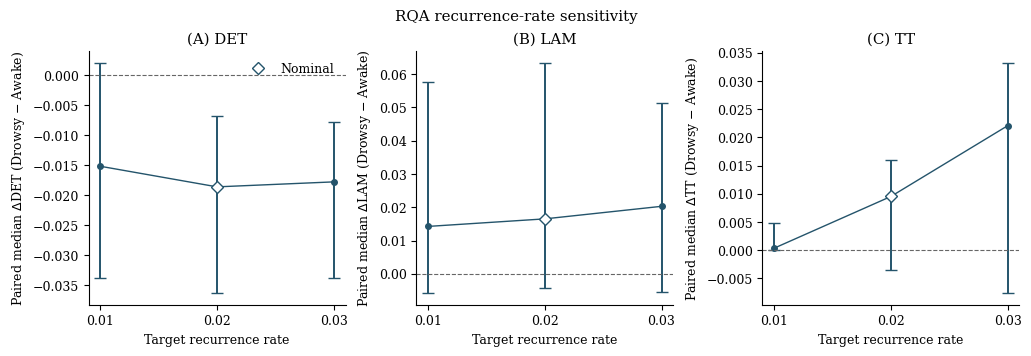

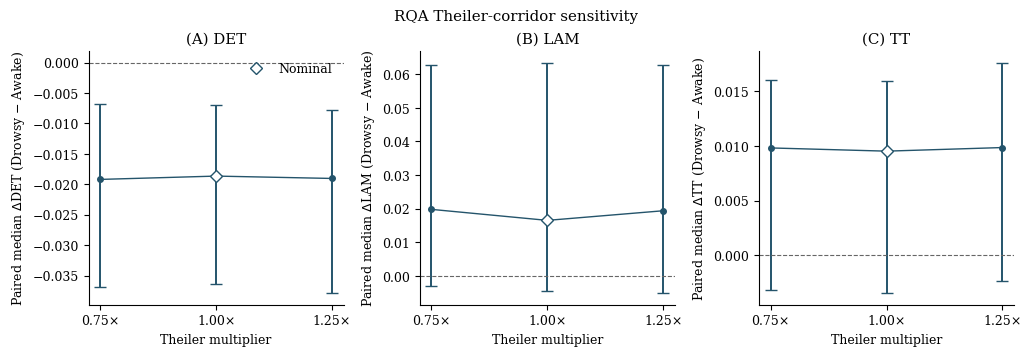

In [8]:
# Publication-ready inline figures
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "font.size": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})


def sensitivity_figure(summary, settings, nominal, xlabel, labels, title):
    figure, axes = plt.subplots(1, 3, figsize=(10.2, 3.45), layout="constrained")
    x = np.arange(len(settings))
    nominal_position = list(settings).index(nominal)
    for axis, metric, panel in zip(axes, METRICS, "ABC"):
        selected = (
            summary.loc[summary["metric"].eq(metric)]
            .set_index("setting").reindex(settings)
        )
        axis.vlines(x, selected["ci_low"], selected["ci_high"], color="#24546b", lw=1.4)
        axis.plot(x, selected["median_delta"], "o-", color="#24546b", lw=1.0, ms=4)
        axis.plot(x, selected["ci_low"], "_", color="#24546b", ms=8)
        axis.plot(x, selected["ci_high"], "_", color="#24546b", ms=8)
        axis.plot(
            nominal_position, selected.iloc[nominal_position]["median_delta"],
            marker="D", mfc="white", mec="#24546b", ms=6, ls="none",
            label="Nominal",
        )
        axis.axhline(0, color="0.4", ls="--", lw=.8)
        axis.set_xticks(x, labels)
        axis.set_xlabel(xlabel)
        axis.set_ylabel(rf"Paired median $\Delta${metric} (Drowsy $-$ Awake)")
        axis.set_title(f"({panel}) {metric}")
    axes[0].legend(frameon=False)
    figure.suptitle(title)
    plt.show()


sensitivity_figure(
    rr_inference, RR_VALUES, NOMINAL_RR, "Target recurrence rate",
    ["0.01", "0.02", "0.03"], "RQA recurrence-rate sensitivity",
)
sensitivity_figure(
    theiler_inference, THEILER_MULTIPLIERS, 1.0, "Theiler multiplier",
    ["0.75×", "1.00×", "1.25×"], "RQA Theiler-corridor sensitivity",
)

In [9]:
# Final summary and pre-specified qualitative decision
def assess_metric(summary, metric, nominal_setting):
    selected = summary.loc[summary["metric"].eq(metric)].copy()
    nominal_effect = float(
        selected.loc[np.isclose(selected["setting"], nominal_setting), "median_delta"].iloc[0]
    )
    effects = selected["median_delta"].to_numpy(float)
    same_direction = bool(
        nominal_effect != 0 and np.all(np.sign(effects) == np.sign(nominal_effect))
    )
    if not same_direction:
        return "PARAMETER-SENSITIVE"
    relative_change = float(np.max(np.abs(effects - nominal_effect)) / abs(nominal_effect))
    if relative_change <= 0.35 and selected["paired_sessions"].eq(20).all():
        return "ROBUST"
    return "MODERATELY SENSITIVE"


assessments = {}
for sensitivity, summary, nominal_setting in (
    ("RR", rr_inference, NOMINAL_RR),
    ("Theiler", theiler_inference, 1.0),
):
    for metric in METRICS:
        assessments[(sensitivity, metric)] = assess_metric(
            summary, metric, nominal_setting
        )

final_parts = []
for sensitivity, summary in (("RR", rr_inference), ("Theiler", theiler_inference)):
    part = summary.copy()
    part.insert(0, "Sensitivity", sensitivity)
    part["Setting"] = part["setting"].map(
        lambda value: f"RR={value:.2f}" if sensitivity == "RR" else f"W={value:.2f}×"
    )
    part["95% CI"] = part.apply(
        lambda row: f"[{row.ci_low:.6f}, {row.ci_high:.6f}]", axis=1
    )
    part["Direction"] = part.apply(
        lambda row: (
            f"{row.n_negative}/{row.paired_sessions} negative; "
            f"{row.n_positive} positive; {row.n_zero} zero"
        ), axis=1
    )
    part["Assessment"] = part["metric"].map(
        lambda metric: assessments[(sensitivity, metric)]
    )
    final_parts.append(part.rename(columns={
        "metric": "Metric", "valid_windows": "Valid windows",
        "paired_sessions": "Paired sessions", "median_delta": "Median Δ",
        "r_rb": "r_rb", "p": "p",
    })[[
        "Sensitivity", "Setting", "Metric", "Valid windows",
        "Paired sessions", "Median Δ", "95% CI", "r_rb",
        "Direction", "p", "Assessment",
    ]])

final_summary = pd.concat(final_parts, ignore_index=True)
display(Markdown("## Final RQA robustness summary"))
display(final_summary.round({"Median Δ": 6, "r_rb": 4, "p": 6}))

conclusion_table = pd.DataFrame([
    ["RR sensitivity", assessments[("RR", "DET")], "Headline DET"],
    ["Theiler sensitivity", assessments[("Theiler", "DET")], "Headline DET"],
    ["LAM across both experiments", ", ".join(sorted(set(
        assessments[(name, "LAM")] for name in ("RR", "Theiler")
    ))), "Secondary"],
    ["TT across both experiments", ", ".join(sorted(set(
        assessments[(name, "TT")] for name in ("RR", "Theiler")
    ))), "Secondary"],
    ["Reproducibility", "PASS" if audit_pass and full_nominal_audit_pass else "FAIL", "Current wrapper/public core and 901-window cross-branch nominal audit"],
    ["Legacy-cache provenance", f"{int(mismatch_mask.sum())} mismatches in {', '.join(legacy_mismatch_sessions)}", "Explained by former linear-quantile tie boundary; cache retained"],
], columns=["Component", "Conclusion", "Role"])
display(conclusion_table)

verification_complete = bool(
    audit_pass
    and full_nominal_audit_pass
    and all(value != "PARAMETER-SENSITIVE" for value in assessments.values())
)
final_status = "COMPLETE" if verification_complete else "NEEDS FOLLOW-UP"
display(Markdown(
    "The nominal RR and Theiler rule remain unchanged. Settings are evaluated from "
    "direction, magnitude, uncertainty, rank-biserial effect, direction count, "
    "window validity, and paired-session coverage; no setting is selected from its p-value.\n\n"
    "The current tie-safe core is the verification reference. The older nominal cache "
    "is retained for provenance and its diagnosed tie-boundary mismatch is not silently overwritten.\n\n"
    f"> **RQA verification status: {final_status}**"
))

## Final RQA robustness summary

,Sensitivity,Setting,Metric,Valid windows,Paired sessions,Median Δ,95% CI,r_rb,Direction,p,Assessment
0,RR,RR=0.01,DET,901,20,-0.015214,"[-0.033764, 0.002064]",-0.4476,14/20 negative; 6 positive; 0 zero,0.082550,ROBUST
1,RR,RR=0.01,LAM,901,20,0.014242,"[-0.005819, 0.057725]",0.3905,7/20 negative; 13 positive; 0 zero,0.132727,ROBUST
2,RR,RR=0.01,TT,901,20,0.000343,"[-0.000043, 0.004808]",0.3529,6/20 negative; 10 positive; 4 zero,0.214602,MODERATELY SENSITIVE
3,RR,RR=0.02,DET,901,20,-0.018645,"[-0.036354, -0.006899]",-0.5810,15/20 negative; 5 positive; 0 zero,0.021484,ROBUST
4,RR,RR=0.02,LAM,901,20,0.016509,"[-0.004361, 0.063484]",0.3810,7/20 negative; 13 positive; 0 zero,0.142906,ROBUST
5,RR,RR=0.02,TT,901,20,0.009515,"[-0.003444, 0.015962]",0.3333,6/20 negative; 14 positive; 0 zero,0.202450,MODERATELY SENSITIVE
6,RR,RR=0.03,DET,901,20,-0.017813,"[-0.033859, -0.007863]",-0.5810,15/20 negative; 5 positive; 0 zero,0.021484,ROBUST
7,RR,RR=0.03,LAM,901,20,0.020281,"[-0.005463, 0.051395]",0.4476,7/20 negative; 13 positive; 0 zero,0.082550,ROBUST
8,RR,RR=0.03,TT,901,20,0.022063,"[-0.007639, 0.033264]",0.2762,6/20 negative; 14 positive; 0 zero,0.294252,MODERATELY SENSITIVE
9,Theiler,W=0.75×,DET,901,20,-0.019191,"[-0.036836, -0.006809]",-0.5810,15/20 negative; 5 positive; 0 zero,0.021484,ROBUST


,Component,Conclusion,Role
0,RR sensitivity,ROBUST,Headline DET
1,Theiler sensitivity,ROBUST,Headline DET
2,LAM across both experiments,ROBUST,Secondary
3,TT across both experiments,"MODERATELY SENSITIVE, ROBUST",Secondary
4,Reproducibility,PASS,Current wrapper/public core and 901-window cro...
5,Legacy-cache provenance,55 mismatches in sample_12,Explained by former linear-quantile tie bounda...


The nominal RR and Theiler rule remain unchanged. Settings are evaluated from direction, magnitude, uncertainty, rank-biserial effect, direction count, window validity, and paired-session coverage; no setting is selected from its p-value.

The current tie-safe core is the verification reference. The older nominal cache is retained for provenance and its diagnosed tie-boundary mismatch is not silently overwritten.

> **RQA verification status: COMPLETE**

# Tổng kết RQA robustness verification

## Phạm vi và cấu hình cố định

- Phân tích **901 processed PPG windows dài 60 s** thuộc **20 paired sessions**, chỉ gồm các window thỏa `analysis_included=True` cùng SQI và processed-stationarity mask hiện tại.
- Phase-space reconstruction: `m=8`, `τ=0.16 s`; khoảng cách Euclidean; `lmin=2`, `vmin=2`; thresholding tie-safe.
- Nominal recurrence rate: `RR=0.02`.
- Nominal Theiler corridor: `W=(m-1)τ`, tương ứng **28 samples tại 25 Hz** và **56 samples tại 50 Hz** (xấp xỉ **1.12 s**).
- Inference chuẩn: median các window hợp lệ trong từng `session × state` → paired `Δ = Drowsy − Awake`; percentile bootstrap 95% CI với 20,000 resamples, two-sided Wilcoxon, matched-pairs rank-biserial `r_rb`, và direction count.

## Kết quả tại nominal point

| Metric | Paired median Δ | Bootstrap 95% CI | `r_rb` | Direction count | Wilcoxon `p` |
|---|---:|---:|---:|---:|---:|
| DET | -0.018645 | [-0.036354, -0.006899] | -0.5810 | 15 negative / 5 positive | 0.021484 |
| LAM | +0.016509 | [-0.004361, +0.063484] | +0.3810 | 13 positive / 7 negative | 0.142906 |
| TT | +0.009515 | [-0.003444, +0.015962] | +0.3333 | 14 positive / 6 negative | 0.202450 |

Mỗi nominal estimate sử dụng **901 valid windows** và đủ **20 paired sessions**.

## Sensitivity results

| Sensitivity | Grid | DET | LAM | TT | Đánh giá |
|---|---|---|---|---|---|
| Recurrence rate | `RR=0.01, 0.02, 0.03` | Δ luôn âm: -0.015214 đến -0.018645 | Δ luôn dương: +0.014242 đến +0.020281 | Δ luôn dương nhưng thay đổi +0.000343 đến +0.022063 | DET và LAM **ROBUST**; TT **MODERATELY SENSITIVE** |
| Theiler corridor | `0.75×, 1.00×, 1.25×` | Δ luôn âm: -0.018645 đến -0.019191 | Δ luôn dương: +0.016509 đến +0.019785 | Δ luôn dương: +0.009515 đến +0.009844 | DET, LAM và TT **ROBUST** |

Cả sáu sensitivity batches đều giữ đủ **901 valid windows** và **20 paired sessions**. Achieved RR nằm trong tolerance tie-safe hiện tại; epsilon được tính lại riêng cho từng window và từng admissible region.

## Reproducibility audit

- Custom-Theiler wrapper tái tạo chính xác public RQA core trên audit windows: **max absolute difference = 0**.
- Hai nhánh nominal (`RR=0.02` và Theiler `1.00×`) khớp trên toàn bộ **901 windows** cho epsilon, achieved RR, DET, LAM và TT: **max absolute difference = 0; mismatch = 0**.
- Cache nominal cũ có **55 mismatch**, chỉ thuộc `sample_12`. Nguyên nhân được xác định là linear-quantile threshold cũ tại tie boundary; đây không phải sai khác về dữ liệu, embedding hay RQA metric. Cache cũ được giữ nguyên để bảo toàn provenance, còn current tie-safe core là verification reference.

## Kết luận

Headline **DET robust** đối với cả RR và Theiler perturbation. **LAM robust** trong cả hai thí nghiệm. **TT robust với Theiler** nhưng nhạy vừa phải về magnitude theo RR; direction không đổi và không làm thay đổi kết luận chính. Nominal `RR=0.02` và Theiler rule đã freeze được giữ nguyên, không lựa chọn lại theo p-value.

> **RQA verification status: COMPLETE**


# Với RQA, em tập trung sensitivity vào hai tham số nội tại quan trọng nhất là recurrence rate và Theiler corridor. DET giữ hiệu ứng âm ổn định khi RR thay đổi từ 1% đến 3% và khi Theiler thay đổi ±25%, trong khi toàn bộ 901 window và 20 session vẫn được giữ. LAM và TT cũng giữ nguyên hướng, dù TT nhạy hơn về độ lớn theo RR. Ngoài ra em audit lại implementation và nominal outputs tái lập chính xác; sai khác với cache cũ được truy ra do cách xử lý tie ở threshold. Vì vậy em coi RQA đã đủ robustness và reproducibility để freeze.